In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from datetime import datetime
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('c_rate&cell_deviation_reg_data.csv')

In [3]:
df.columns

Index(['vin', 'intime', 'cyclenum', 'soc', 'imei', 'cycletime', 'state',
       'state1', 'tcu_speedmode', 'tcu_param', 'vehiclespeed', 'percthrottle',
       'odometer', 'battcurrent', 'packvoltage', 'kwh', 'bv1', 'bv2', 'bv3',
       'bv4', 'bv5', 'bv6', 'bv7', 'bv8', 'bv9', 'bv10', 'bv11', 'bv12',
       'bv13', 'bv14', 'bv15', 'bv16', 'bv17', 'bv18', 'bv19', 'bv20', 'bv21',
       'bv22', 'bv23', 'bv24', 'bt1', 'bt2', 'bt3', 'bt4', 'contollertemp',
       'ampherehour', 'batt_packtemp'],
      dtype='object')

In [4]:
df.head()

,vin,intime,cyclenum,soc,imei,cycletime,state,state1,tcu_speedmode,tcu_param,vehiclespeed,percthrottle,odometer,battcurrent,packvoltage,kwh,bv1,bv2,bv3,bv4,bv5,bv6,bv7,bv8,bv9,bv10,bv11,bv12,bv13,bv14,bv15,bv16,bv17,bv18,bv19,bv20,bv21,bv22,bv23,bv24,bt1,bt2,bt3,bt4,contollertemp,ampherehour,batt_packtemp
0,MB7U8CLLTLJB30266,2020-06-21 06:48:21.000,0,0.0,357851070261982,0:0:0,0,0,reserved,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.0,NaN
1,MB7U8CLLTLJB30266,2020-06-21 06:50:22.000,0,0.0,357851070261982,0:0:0,0,0,reserved,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.0,NaN
2,MB7U8CLLTLJB30266,2020-06-21 06:52:22.000,0,0.0,357851070261982,0:0:0,0,0,reserved,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.0,NaN
3,MB7U8CLLTLJB30352,2020-06-21 09:37:17.000,0,0.0,357851070447466,0:0:0,0,0,reserved,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.0,NaN
4,MB7A8CLLTLJA30161,2020-06-21 14:26:11.000,0,0.0,357851070448886,0:0:0,0,0,reserved,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.0,NaN


In [5]:
charge_number_profile = [20,21,22,24,23,26,28,29,40,41,42,43,46,47,48]
fastcharge_profile = ['FastCharge:C1','FastCharge:C2',
                            'FastCharge:CC','FastCharge:CH','FastCharge:CI','FastCharge:CB','FastCharge:CP',
                            'FastCharge:CQ','FastCharge:CT']

In [8]:
charge_data = df.loc[df['state'].isin(charge_number_profile)]
charge_data.vin.unique()

array(['MB7U8CLLTLJB30352', 'MB7U8CLLTKJA30095', 'MB7U8CLLTKJJ30364',
       'MB7U8CLLTLJB30488', 'MB7A8CLLTKJL30610', 'MB7U8CLLTKJJ30355',
       'MB7U8CLLTKJL30561', 'MB7U8CLLTKJA30077', 'MB7U8CLLTLJA30088',
       'MB7U8CLLTLJB30374', 'MB7U8CLLTLJB30266', 'MB7U8CLLTLJB30497',
       'MB7U8CLLTLJB30331', 'MB7U8CLLTKJL30552', 'MB7U8CLLTLJB30493',
       'MB7A8CLLTLJA30161', 'MB7U8CLLTLJB30355'], dtype=object)

In [9]:
vin_data = charge_data[charge_data['vin']=='MB7U8CLLTLJB30352']
vin_data.head()

,vin,intime,cyclenum,soc,imei,cycletime,state,state1,tcu_speedmode,tcu_param,vehiclespeed,percthrottle,odometer,battcurrent,packvoltage,kwh,bv1,bv2,bv3,bv4,bv5,bv6,bv7,bv8,bv9,bv10,bv11,bv12,bv13,bv14,bv15,bv16,bv17,bv18,bv19,bv20,bv21,bv22,bv23,bv24,bt1,bt2,bt3,bt4,contollertemp,ampherehour,batt_packtemp
676,MB7U8CLLTLJB30352,2021-11-06 08:31:46.000,298,99.1,357851070447466,1:3:10,26,2,reserved,NaN,0.0,0.0,18885.0,-0.8,59.0,1.94,3.311,3.329,3.478,3.332,3.332,3.333,3.333,3.366,3.333,3.335,3.335,3.335,3.337,3.338,3.338,3.337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.2,26.5,27.5,26.5,205.0,36.12,NaN
2375,MB7U8CLLTLJB30352,2021-09-29 21:18:20.000,249,72.9,357851070447466,1:30:58,21,2,reserved,NaN,0.0,0.0,17151.0,36.2,0.0,2.91,3.332,3.372,3.375,3.374,3.348,3.354,3.377,3.387,0.036,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,205.0,54.57,NaN
2435,MB7U8CLLTLJB30352,2021-09-29 21:42:02.000,249,84.1,357851070447466,1:54:36,21,2,reserved,NaN,0.0,0.0,17151.0,36.3,59.0,3.68,3.341,3.375,3.377,3.375,3.361,3.375,3.377,3.390,3.382,3.366,3.382,3.382,3.378,3.370,3.364,3.382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.3,33.1,35.8,33.7,205.0,68.84,NaN
3492,MB7U8CLLTLJB30352,2021-10-29 15:26:49.000,289,62.0,357851070447466,0:48:3,21,2,reserved,NaN,0.0,0.0,18611.0,36.2,59.0,1.53,3.316,3.341,3.345,3.343,3.338,3.340,3.345,3.354,3.345,3.341,3.348,3.345,3.343,3.341,3.341,3.343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.6,32.2,32.6,32.4,205.0,28.83,NaN
6296,MB7U8CLLTLJB30352,2021-10-28 07:14:49.000,287,93.7,357851070447466,0:23:59,21,2,reserved,NaN,0.0,0.0,18543.0,36.0,59.0,0.76,3.369,3.388,3.391,3.391,3.390,3.393,3.393,3.403,3.398,3.393,3.399,3.396,3.396,3.395,3.393,3.396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.0,25.8,26.3,25.9,205.0,14.19,NaN


In [40]:
vin_data['intime_ist'] = pd.to_datetime(vin_data['intime'])
vin_data.sort_values(['odometer','intime_ist'], inplace = True)
vin_data.reset_index(drop = True)
        
intime_start = vin_data.groupby(["odometer"])["intime_ist"].first().to_frame()
intime_end =vin_data.groupby(["odometer"])["intime_ist"].last().to_frame()

charge_duration = ((intime_end['intime_ist']-intime_start['intime_ist']).dt.total_seconds()/3600).to_frame().reset_index()
charge_duration = charge_duration[(charge_duration['odometer'] > 0) & (charge_duration['intime_ist'] > 0) & (charge_duration['intime_ist'] < 24)].reset_index(drop = True)
charge_duration

/var/folders/my/07f5nb2j5r93lzd5_vt01ztc0000gn/T/ipykernel_42851/311132433.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/my/07f5nb2j5r93lzd5_vt01ztc0000gn/T/ipykernel_42851/311132433.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,odometer,intime_ist
0,1363.0,0.933333
1,1429.0,0.793333
2,1430.0,11.170833
3,1456.0,1.133333
4,1494.0,0.233333
...,...,...
913,36782.0,1.366667
914,36803.0,1.108889
915,36823.0,0.533333
916,36831.0,1.066667


<AxesSubplot: xlabel='odometer'>

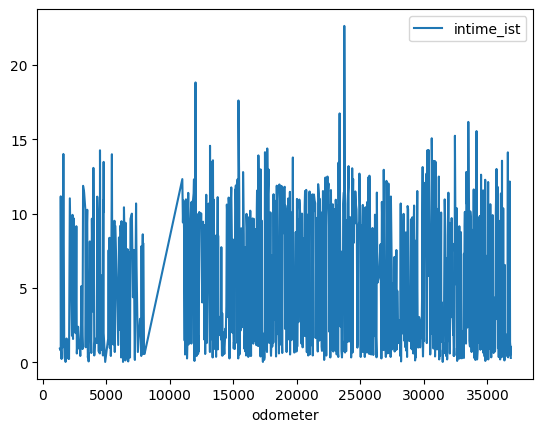

In [45]:
charge_duration.plot('odometer','intime_ist')

In [42]:
charge_duration.sort_values(['intime_ist'])

,odometer,intime_ist
76,4927.0,0.033333
102,6330.0,0.033333
334,17337.0,0.033333
10,1807.0,0.033333
726,31483.0,0.033333
...,...,...
791,33497.0,16.177778
495,23372.0,16.748889
280,15412.0,17.618611
170,12035.0,18.831944
